In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import squidpy as sq
from matplotlib import pyplot as plt

In [11]:
adata_tfa=sc.read_h5ad("out/stf_results_tfa_only.h5ad")
adata_raw=sc.read_h5ad("data/visium_lymph_node.h5ad")
cytokine_list=pd.read_csv(
    "data/kegg_cytokine.txt").iloc[:,0].to_list()
cytokine_list=np.intersect1d(adata_raw.var_names, cytokine_list).tolist()

In [12]:
sq.gr.spatial_neighbors(adata_raw ,n_rings=1)
sc.pp.normalize_total(adata_raw)
sc.pp.sqrt(adata_raw)

In [13]:
tf_df=adata_tfa.to_df()

In [14]:
cytokine_df=sc.get.obs_df(adata_raw, cytokine_list)
cytokine_neighbor_df=pd.DataFrame(
    (adata_raw.obsp['spatial_connectivities'] + np.eye(adata_raw.n_obs)).dot(cytokine_df)/(1+adata_raw.obsp['spatial_connectivities'].sum(axis=1)),
    index=cytokine_df.index,
    columns=cytokine_df.columns)

In [15]:
corr_df = pd.DataFrame({x: tf_df.corrwith(cytokine_neighbor_df[x]) for x in cytokine_list})

In [16]:
corr_df.max().sort_values(ascending=False).head(20)

CCL19       0.612555
CXCL13      0.600619
CCL21       0.571958
CXCL10      0.563570
CCL2        0.547820
FLT3LG      0.545513
CXCL12      0.508958
TNFSF10     0.505142
CXCL11      0.502862
CCL18       0.462200
CCL17       0.442485
CXCR4       0.441251
CCL14       0.440374
CD40LG      0.406947
CXCR5       0.396824
CXCL9       0.394912
CCL20       0.372131
LTB         0.358770
CCL5        0.350762
TNFSF13B    0.344837
dtype: float64

In [17]:
corr_df["CCL19"].sort_values() #STAT5 signaling

RFX3     -0.591631
CREB1    -0.543706
SPIB     -0.530482
TCF12    -0.525241
PBX1     -0.504230
            ...   
HIF1A     0.447769
TFAP2C    0.461585
MYB       0.483025
STAT5B    0.515141
TBX21     0.612555
Name: CCL19, Length: 234, dtype: float64

In [ ]:
corr_df["CXCL11"].sort_values()
#https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6178135/

In [48]:
import seaborn as sns

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


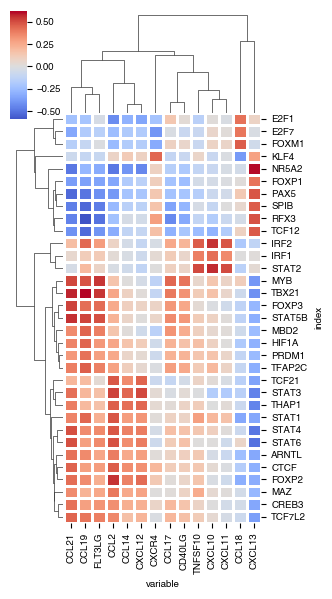

In [76]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.sans-serif': 'Helvetica'})
plt.rcParams.update({'font.size': 7})
corr_df.melt(ignore_index=False).reset_index().query("value>0.4").pivot_table(index='index', columns='variable', values='value', fill_value=0)
corr_df_abridged=corr_df.melt(ignore_index=False).reset_index().query("value>0.4").pivot_table(index='index', columns='variable', values='value', fill_value=0)
corr_df_abridged=corr_df.loc[corr_df_abridged.index, corr_df_abridged.columns]
sns.clustermap(corr_df_abridged, cmap='coolwarm', figsize=(3.3,6), linewidth=1, center=0)

plt.savefig("figures/tf_lg_clustermap.pdf", bbox_inches='tight', pad_inches=0)

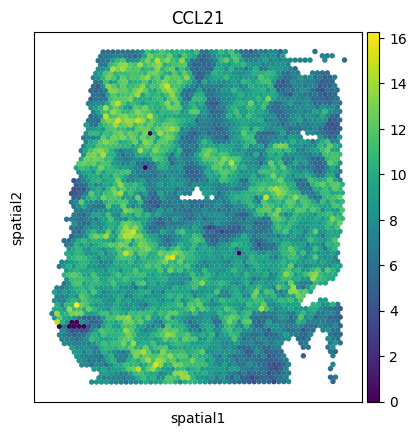

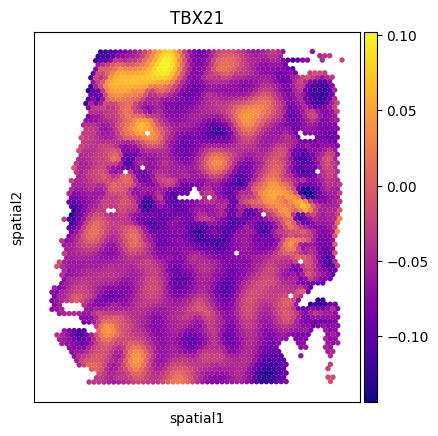

In [10]:
sc.pl.spatial(adata_raw, color="CCL21", alpha_img=0, size=1.7)
sc.pl.spatial(adata_tfa, color="TBX21", alpha_img=0, size=1.7, cmap="plasma")

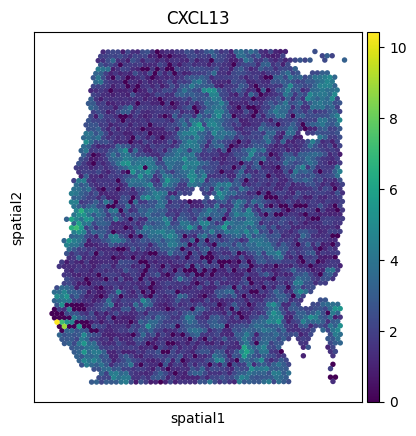

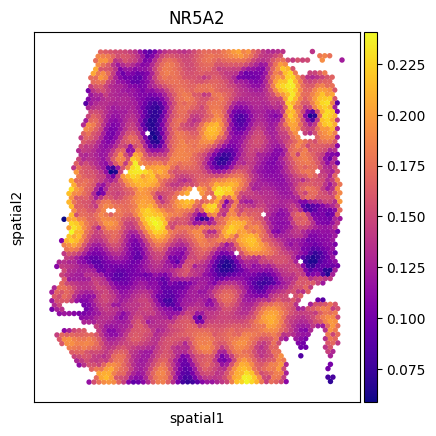

In [14]:
sc.pl.spatial(adata_raw, color="CXCL13", alpha_img=0, size=1.7)
sc.pl.spatial(adata_tfa, color="NR5A2", alpha_img=0, size=1.7, cmap="plasma")

In [33]:
corr_df.melt(ignore_index=False).query("value>0.4")

,variable,value
STAT3,CCL14,0.440374
THAP1,CCL14,0.416569
MYB,CCL17,0.442485
E2F1,CCL18,0.413154
E2F7,CCL18,0.405185
...,...,...
TBX21,TNFRSF25,0.551819
TCF7L2,TNFRSF25,0.434536
TFAP2C,TNFRSF25,0.450862
IRF2,TNFSF10,0.464547


In [24]:
tfs=corr_df.melt(ignore_index=False).query("value>0.4").index.unique()
genes=corr_df.melt(ignore_index=False).query("value>0.4")["variable"].unique()

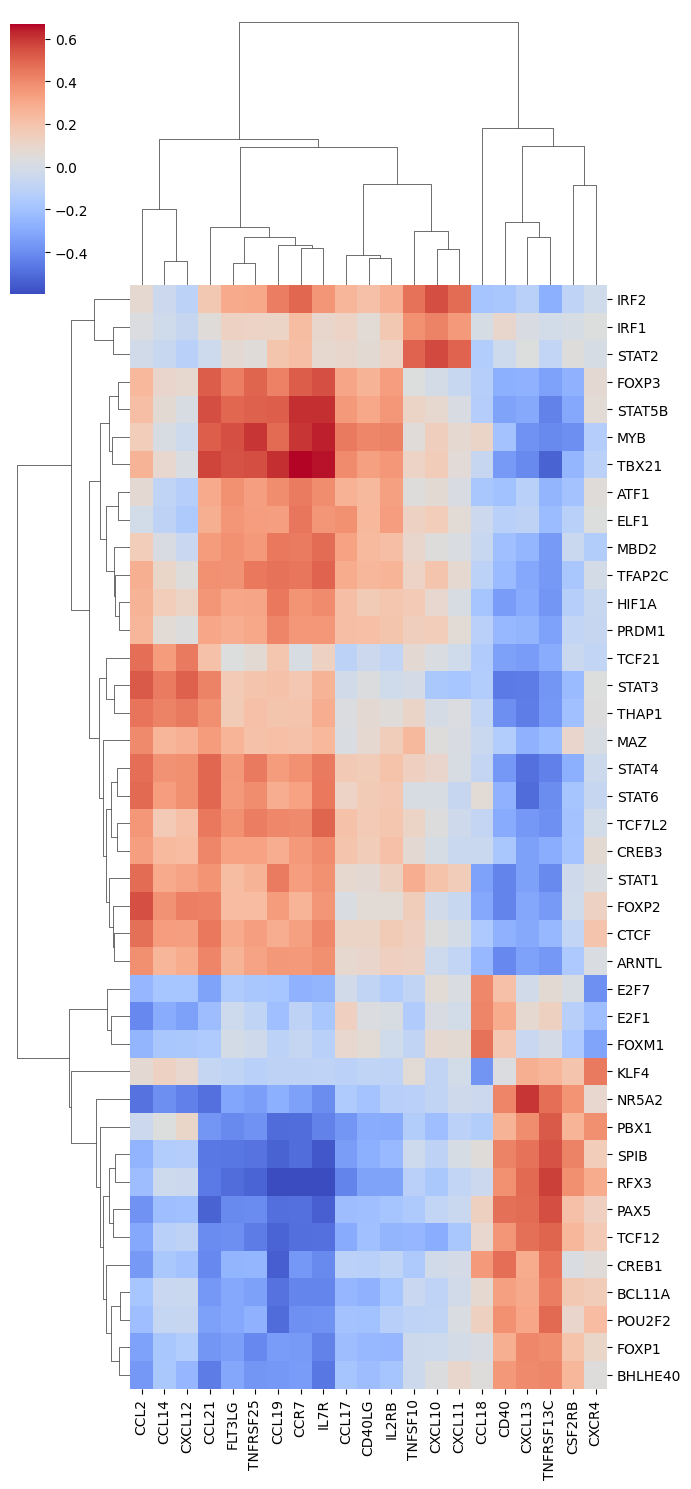

In [32]:
import seaborn as sns
sns.clustermap(corr_df.loc[tfs, genes], cmap='coolwarm', figsize=(7,15))

In [ ]:
fig, ax = plt.subplots(figsize= (10,7))

ax.scatter(np.arange(cxcl_cor.shape[0]),cxcl_cor, s=50, alpha=0.8)

TEXTS = []
y_point=[]
for i in range(5):
    x = i
    y_point.append(cxcl_cor.iloc[i])
    y_text=cxcl_cor.iloc[i]+0.02*i
    text = cxcl_cor.index[i]
    TEXTS.append(ax.text(-10, y_text, text, fontsize=14, ha='right', va='center'))
    plt.arrow(-10, y_text, i+10, -0.02*i)

#plt.arrow(-20, y_text, 20-x, -y_text+cors[np.argsort(cors)[i]])
for i in range(5):
    x = len(cxcl_cor)-i-1
    y_point.append(cxcl_cor.iloc[x])
    y_text=cxcl_cor.iloc[x]-0.02*i
    text = cxcl_cor.index[x]
    TEXTS.append(ax.text(240, y_text, text, fontsize=14, ha='left', va='center'))
    plt.arrow(240, y_text, -(240-x), 0.02*i)

# for i in range(n_labels):
#     x = len(cors)-i-1
#     y_text = 1-0.07*i
#     y_point.append(cors[np.argsort(cors)[x]])
#     text = cors.index[np.argsort(cors)[x]]
#     TEXTS.append(ax.text(260, y_text, text, fontsize=14))


ax.set_ylabel("Correlation", fontdict={"size": 16})
ax.set_xlabel("Transcription Factor", fontdict={"size": 16})
# ax.set_title(title,fontdict={"size": 18})
plt.xlim(-40,270)
plt.xticks(fontsize=14)